In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq, RR3_gate
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, display_table, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt

##### RR3 import test

In [3]:
rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 10

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1
initial_state[17] = 0
initial_state[18] = -2
initial_state[19] = 0
initial_state[20] = 3j
initial_state[21] = 0
initial_state[22] = -4j                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
initial_state[23] = 0
# initial_state[24] = 0

initial_state = initial_state/ np.linalg.norm(initial_state)

wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state, d_shift=0)

display_table_compare(basis=basis, init_state=initial_state, final_state=wave_func[-1,:])

+---------+---------------------+------------------+----------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |      Initial Psi |            Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+==================+======================+===================+=================+
|       0 |                 -16 |          0j|000> |              0j|000> |             0     |           0     |
+---------+---------------------+------------------+----------------------+-------------------+-----------------+
|       1 |                 -15 |          0j|001> |             -0j|001> |             0     |           0     |
+---------+---------------------+------------------+----------------------+-------------------+-----------------+
|       2 |                 -14 |          0j|010> |         (-0+0j)|010> |             0     |           0     |
+---------+---------------------+------------------+----------------------+-------------

##### RR3 mom dist

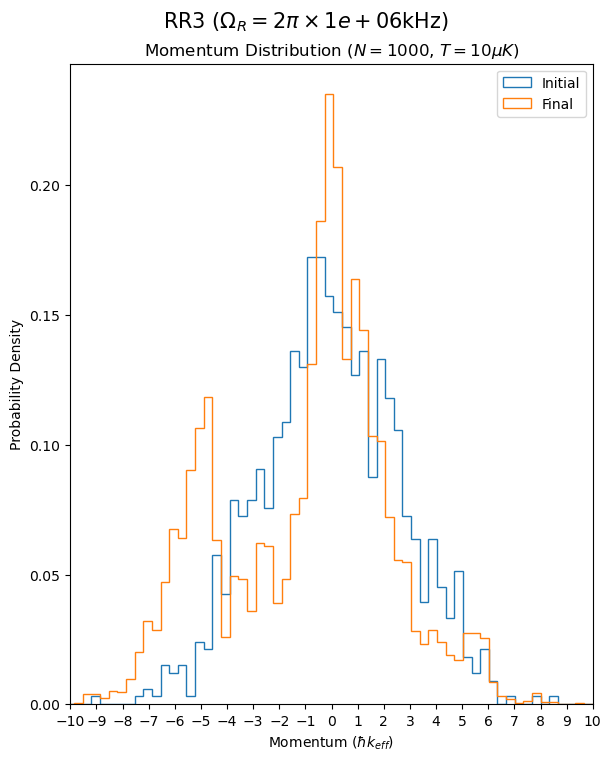

In [10]:
N = 1000
Temp = 10e-6

rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1
# initial_state[17] = 0
# initial_state[18] = 1
# initial_state[19] = 0
# initial_state[20] = 1
# initial_state[21] = 0
# initial_state[22] = 1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
# initial_state[23] = 0
# initial_state[24] = 0

initial_state = initial_state/ np.linalg.norm(initial_state)

# wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state, d_shift=0)

moms, fracs, _ = simulate_pulses_p_dist(pulse_seq=RR3, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state)

moms = moms/(hbar*k_eff)

fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')

plot_hist(ax= ax1, mom_vals= moms, fracs= fracs, n_bins= 150, n_atoms= N, temp=Temp, contains_title= True)

fig1.suptitle(t=rf'RR3 ($\Omega_R = 2\pi\times{rabi_freq/(2*1e3*pi):.3g}$kHz)', fontsize= 15)

xlims = np.arange(-10,11)
ax1.set_xticks(xlims)
ax1.set_xlim(-10,10)

# fig1.tight_layout
plt.show()